# DCIR Simulation with PyBaMM

This notebook demonstrates how to perform Direct Current Internal Resistance (DCIR) simulation using PyBaMM with BYD Blade Prismatic 135Ah cell parameters.

## Overview
- **Cell**: BYD Blade Prismatic 135Ah LFP
- **Chemistry**: LFP (Lithium Iron Phosphate)
- **Form Factor**: Prismatic
- **Nominal Voltage**: 3.3V
- **Capacity**: 135Ah
- **Simulations**: DCIR (7 time points)

## 1. Load Cell Parameters

Load the cell design from the manifest file.

In [14]:
# Import required libraries
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from model_library.spmet_dcir import run_spmet_dcir


## 2. Setup PyBaMM Model Parameters

Configure PyBaMM SPMe (Single Particle Model with electrolyte effects) using the cell design parameters.

In [15]:
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
upper_voltage_cutoff = cell_design_manifest["cell_design"]["upper_voltage_cutoff"]["value"]
lower_voltage_cutoff = cell_design_manifest["cell_design"]["lower_voltage_cutoff"]["value"]
dcir_config = {
    'ambient_temperature': 298.15,
    'initial_temperature': 298.15,
    'contact_resistance': 1e-5,
    'total_heat_transfer_coefficient': 0.01,
    'cooling_surface_area': 0.1,
    'initial_soc': 0.5,
    'upper_voltage_cutoff': upper_voltage_cutoff,
    'lower_voltage_cutoff': lower_voltage_cutoff,
    'period': '0.01 second',
    'experiments': [f'Discharge at 1C for 30 seconds or until {lower_voltage_cutoff} V'],
    'experiment_labels': [f'1C_DCIR'],
}

## 3. Run DCIR Simulation

In [16]:
# Reload modules to get latest changes
import importlib
import sys
if 'model_library.spmet_dcir' in sys.modules:
    from model_library import spmet_dcir
    importlib.reload(spmet_dcir)
    from model_library.spmet_dcir import run_spmet_dcir

# Load cell manifest
manifest_path = "../cells/Tesla_Model3_Prismatic_160Ah_manifest.json"
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    manifest = json.load(f)

cell_design = manifest['cell_design']
kpis = manifest['kpis']

print(f"Cell: {manifest['metadata']['name']}")
print(f"Capacity: {kpis['nominal_capacity']['value']:.1f} Ah")
print(f"Voltage: {kpis['nominal_voltage']['value']:.2f} V nominal")

# Load material properties for separator and electrolyte
for component in ["separator", "electrolyte"]:
    material_name = cell_design[component]["material"]["type"]
    material_file_path = material_path / f"{material_name}.json"
    with open(material_file_path, "r") as mf:
        material_data = json.load(mf)
        cell_design[component]["material"] = material_data

# Load material properties for electrodes
for component in ["negative_electrode", "positive_electrode"]:
    material_name = cell_design[component]["coating"]["formulation"]["primary_active_material"]["name"]
    material_file_path = material_path / f"{material_name}.json"
    with open(material_file_path, "r") as mf:
        material_data = json.load(mf)
        cell_design[component]["material"] = material_data

# Add nominal capacity and energy to cell_design (required by run_spmet_dcir)
cell_design["nominal_capacity"] = {"value": kpis['nominal_capacity']['value'], "unit": "Ah"}
cell_design["nominal_energy"] = {"value": kpis['nominal_energy']['value'], "unit": "Wh"}
cell_design["cell_volume"] = {"value": kpis['cell_volume']['value'], "unit": "L"}

print("\nRunning DCIR simulation at default conditions (50% SOC, 25°C, 1C)...")
print("This may take 1-2 minutes as it includes capacity calibration...\n")

# Run DCIR simulation at default conditions (50% SOC, 25°C, 1C)
try:
    dcir_result = run_spmet_dcir(cell_design, kpis)
    
    if dcir_result and dcir_result.get('success'):
        print('\n✓ DCIR simulation completed successfully!')
        print('\nDCIR values at key time points (mOhm):')
        if 'dcir_mOhm' in dcir_result and dcir_result['dcir_mOhm']:
            for t in sorted(dcir_result['dcir_mOhm'].keys()):
                v = dcir_result['dcir_mOhm'][t]
                print(f'  t={t:.2f}s: {v:.4f} mOhm')
        else:
            print('  (No DCIR values in result)')
    else:
        error_msg = dcir_result.get('error', 'Unknown error') if dcir_result else 'No result returned'
        print(f'✗ Simulation failed: {error_msg}')
        print(f'\nFull result: {dcir_result}')
except Exception as e:
    print(f'✗ Exception during simulation: {str(e)}')
    import traceback
    traceback.print_exc()


Cell: Tesla Model3 Prismatic 160Ah
Capacity: 161.1 Ah
Voltage: 3.20 V nominal

Running DCIR simulation at default conditions (50% SOC, 25°C, 1C)...
This may take 1-2 minutes as it includes capacity calibration...


Building model parameters from manifest...

DCIR PULSE SIMULATION
Conditions: SOC=50%, T=25.0°C, C-rate=1.0

DCIR Results:
----------------------------------------
  t=  0.1s: DCIR = 0.011 mOhm
  t=  1.0s: DCIR = 0.018 mOhm
  t= 10.0s: DCIR = 0.077 mOhm
  t= 18.0s: DCIR = 0.114 mOhm
  t= 30.0s: DCIR = 0.155 mOhm
----------------------------------------
DCIR simulation completed successfully!

✓ DCIR simulation completed successfully!

DCIR values at key time points (mOhm):
  t=0.10s: 0.0109 mOhm
  t=1.00s: 0.0183 mOhm
  t=10.00s: 0.0767 mOhm
  t=18.00s: 0.1139 mOhm
  t=30.00s: 0.1550 mOhm



Plotting DCIR results with overpotential breakdown...


KeyError: 'neg_reaction_V'

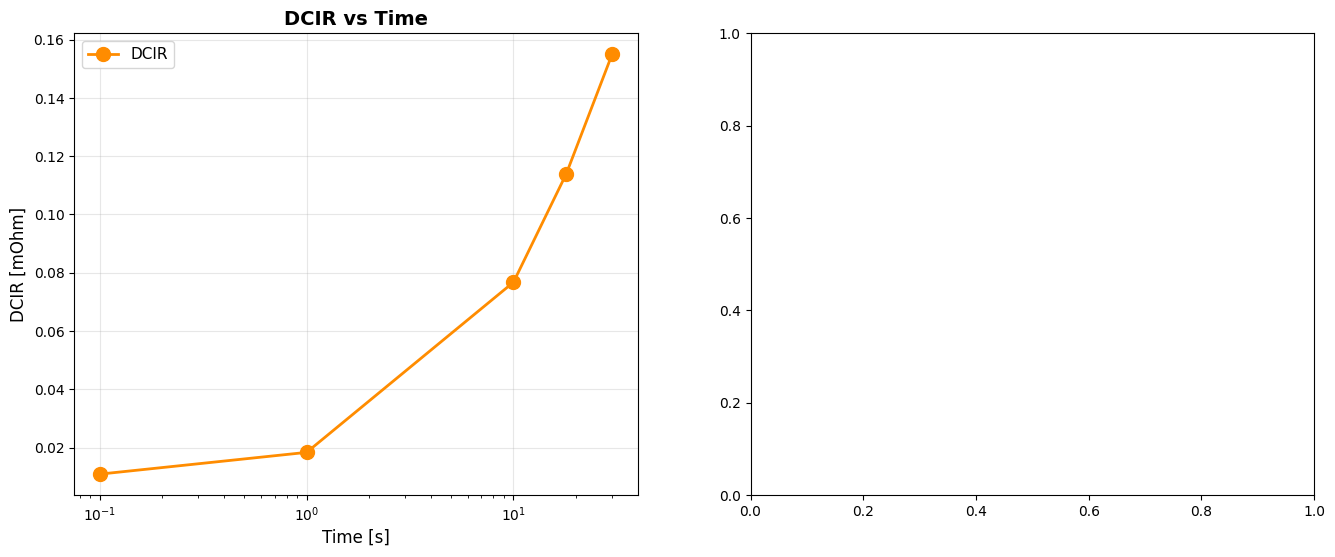

In [ ]:
if dcir_result['success']:
    # Extract data from result
    print("\nPlotting DCIR results with overpotential breakdown...")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Extract time points and DCIR values
    time_points = sorted(dcir_result['dcir_mOhm'].keys())
    dcir_values = [dcir_result['dcir_mOhm'][t] for t in time_points]
    
    # Plot 1: DCIR vs Time
    ax1.plot(time_points, dcir_values, 'o-', linewidth=2, markersize=10, color='darkorange', label='DCIR')
    ax1.set_xlabel('Time [s]', fontsize=12)
    ax1.set_ylabel('DCIR [mOhm]', fontsize=12)
    ax1.set_title('DCIR vs Time', fontsize=14, fontweight='bold')
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)
    
    # Plot 2: Overpotential Breakdown (filled stacked area plot)
    overpots = dcir_result['overpotentials']
    
    # Extract overpotential components (convert to mV for better visualization)
    # Available keys: reaction_overpotential_V, concentration_overpotential_V, sei_overpotential_V, ohmic_overpotential_V
    reaction = np.array([abs(overpots[t]['reaction_overpotential_V']) * 1000 for t in time_points])
    concentration = np.array([abs(overpots[t]['concentration_overpotential_V']) * 1000 for t in time_points])
    sei = np.array([abs(overpots[t]['sei_overpotential_V']) * 1000 for t in time_points])
    ohmic = np.array([abs(overpots[t]['ohmic_overpotential_V']) * 1000 for t in time_points])
    
    # Create stacked data
    y1 = reaction
    y2 = y1 + concentration
    y3 = y2 + sei
    y4 = y3 + ohmic
    
    # Create filled stacked area plot
    ax2.fill_between(time_points, 0, y1, label='Reaction', color='#FF6B6B', alpha=0.8)
    ax2.fill_between(time_points, y1, y2, label='Concentration', color='#4ECDC4', alpha=0.8)
    ax2.fill_between(time_points, y2, y3, label='SEI', color='#45B7D1', alpha=0.8)
    ax2.fill_between(time_points, y3, y4, label='Ohmic', color='#FFEAA7', alpha=0.8)
    
    ax2.set_xlabel('Time [s]', fontsize=12)
    ax2.set_ylabel('Overpotential [mV]', fontsize=12)
    ax2.set_title('Overpotential Breakdown', fontsize=14, fontweight='bold')
    ax2.set_xscale('log')
    ax2.legend(loc='upper left', fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print('\n✓ Plots generated successfully!')
else:
    print('✗ DCIR simulation failed - cannot generate plots')
